Device : cuda
PyTorch: 2.10.0+cu128
  CMU-MOSI Multimodal Sentiment Analysis
  All 11 Improvements + Full Ablation Study
Mounted at /content/drive
Train : 1283 samples
Valid : 214 samples
Test  : 686  samples
  train → Neg: 552  Neu: 228  Pos: 503
  valid → Neg:  78  Neu:  42  Pos:  94
  test  → Neg: 379  Neu: 124  Pos: 183

################################################################################
#  Variant: Full Model
################################################################################

  Training: Full Model
  Params  : 8,389,836
  Ep   TrLoss   TrAcc2   VaLoss   VaAcc2   VaAcc3     VaF1
--------------------------------------------------------------------------------
   1   0.5948   0.4123   0.5945   0.4535   0.3645   0.1947 ◀
   2   0.5831   0.4559   0.5879   0.5814   0.4673   0.4060 ◀
   3   0.5796   0.4445   0.5858   0.6163   0.4953   0.4424 ◀
   4   0.5742   0.4749   0.5873   0.5523   0.4439   0.3969
   5   0.5639   0.5479   0.5831   0.5349   0.4299   0.3829
 

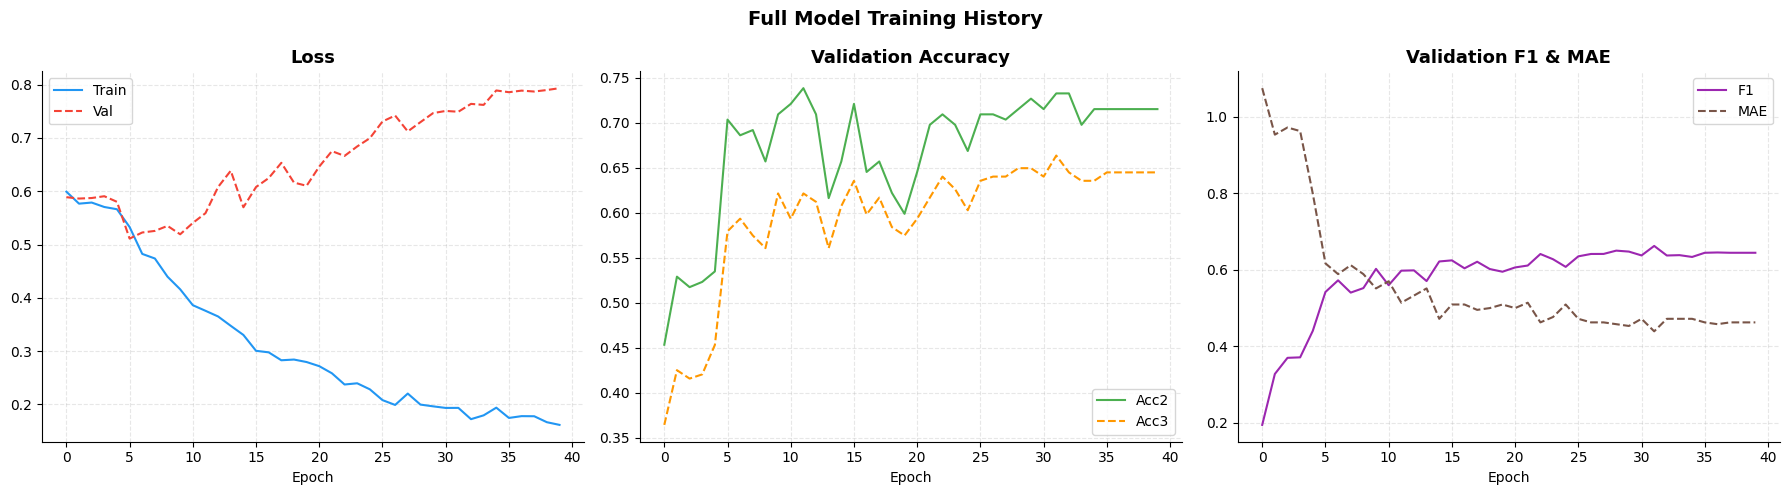

Saved: /content/drive/MyDrive/MOSI_Results/full_model_training_curves.png


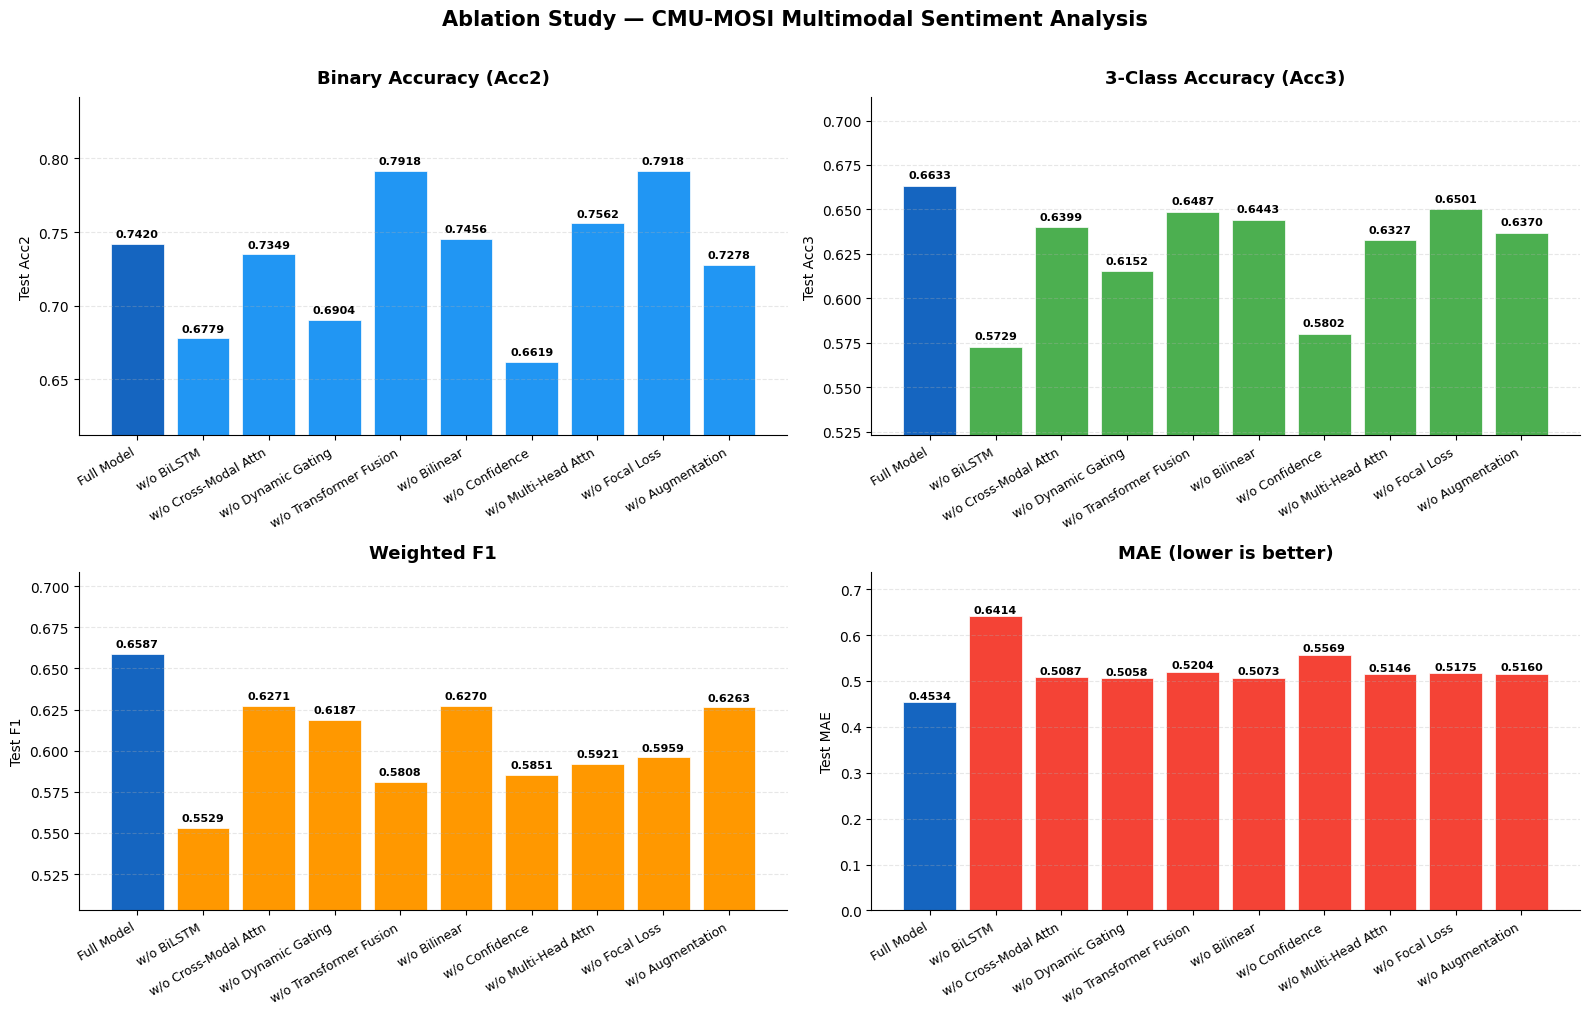

Saved: /content/drive/MyDrive/MOSI_Results/ablation_bar_chart.png


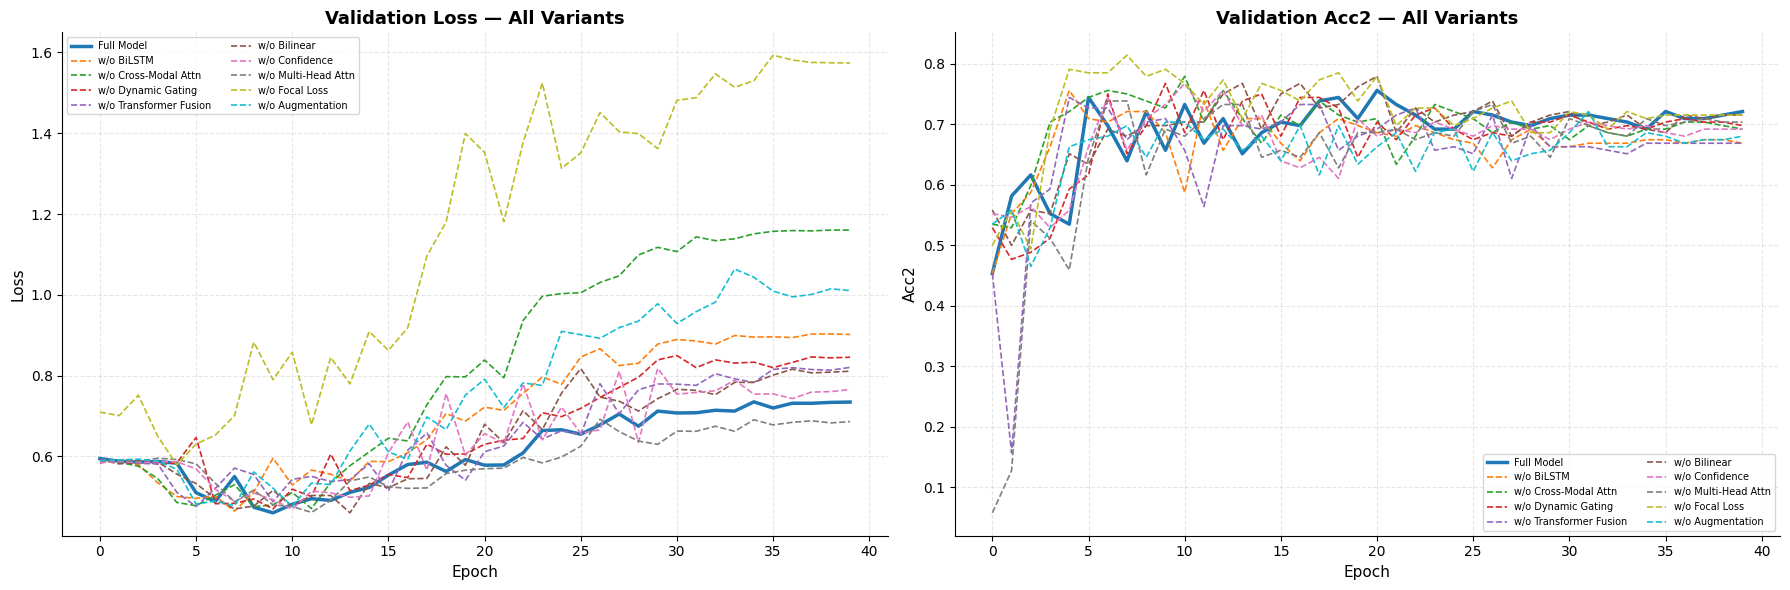

Saved: /content/drive/MyDrive/MOSI_Results/training_curves_all_variants.png


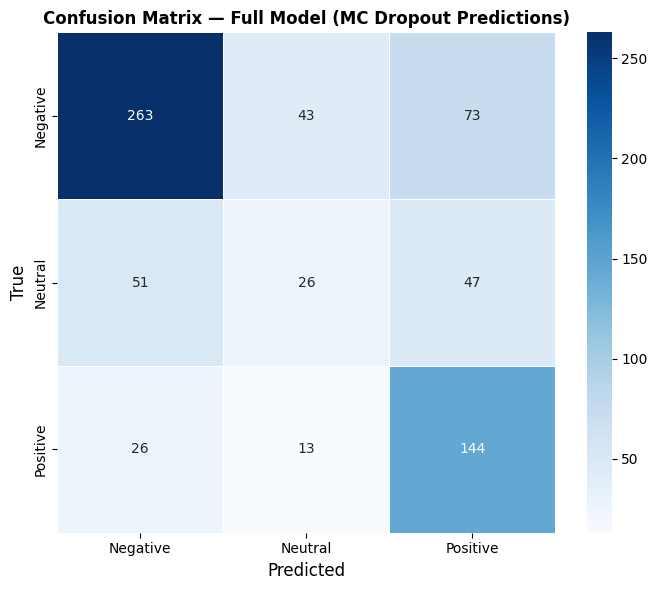

Saved: /content/drive/MyDrive/MOSI_Results/confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.69      0.73       379
     Neutral       0.32      0.21      0.25       124
    Positive       0.55      0.79      0.64       183

    accuracy                           0.63       686
   macro avg       0.55      0.56      0.54       686
weighted avg       0.63      0.63      0.62       686



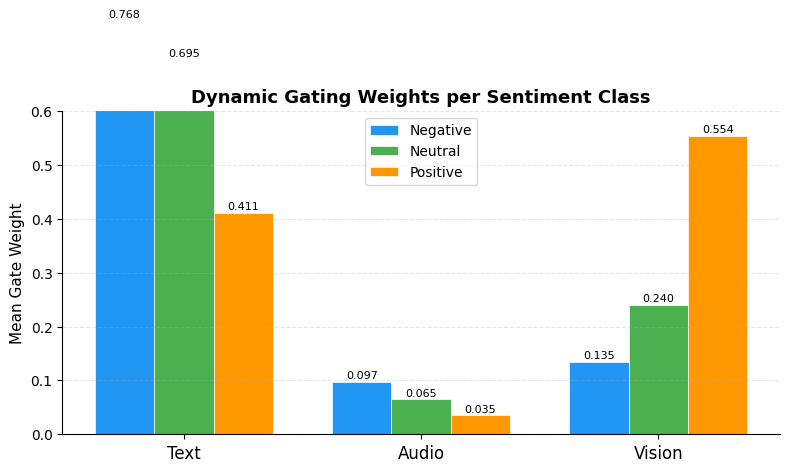

Saved: /content/drive/MyDrive/MOSI_Results/gate_weights_per_class.png


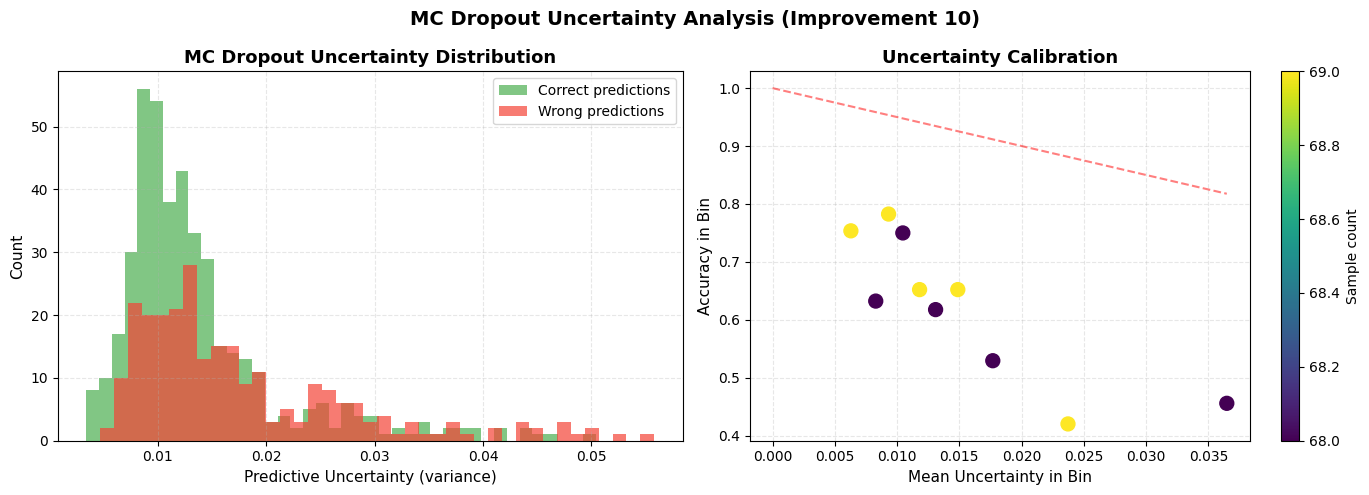

Saved: /content/drive/MyDrive/MOSI_Results/uncertainty_analysis.png

  All done! Files saved to: /content/drive/MyDrive/MOSI_Results/


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   MULTIMODAL SENTIMENT ANALYSIS — CMU-MOSI                                 ║
# ║   Complete Implementation: All 11 Improvements + Full Ablation Study        ║
# ║                                                                              ║
# ║   IMPROVEMENTS INCLUDED:                                                    ║
# ║    1.  Dynamic / context-aware gating                                       ║
# ║    2.  Cross-modal attention (all 6 directed pairs)                         ║
# ║    3.  BiLSTM temporal modeling                                              ║
# ║    4.  Deep pretrained-style encoders (MLP + LayerNorm + GELU)              ║
# ║    5.  Multi-head attention per modality (4 heads)                          ║
# ║    6.  Modality confidence / reliability estimation                          ║
# ║    7.  Transformer-based fusion (CLS token, 2 layers)                       ║
# ║    8.  Focal Loss for class imbalance (Neutral class)                       ║
# ║    9.  Missing / noisy modality robustness (masking + noise)                ║
# ║   10.  MC Dropout uncertainty estimation (20 stochastic passes)             ║
# ║   11.  Bilinear cross-modal feature interaction (3 pairs)                   ║
# ║                                                                              ║
# ║   ABLATION STUDY:                                                           ║
# ║    9 controlled variants — each disables one component at a time            ║
# ║    Full comparison table + bar charts saved to Google Drive                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies (run once, then restart runtime)
# ─────────────────────────────────────────────────────────────────────────────
# !pip install einops --quiet

# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import pickle
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from einops import rearrange
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Global Configuration
# ─────────────────────────────────────────────────────────────────────────────
class Config:
    # ── Paths ────────────────────────────────────────────────────────────────
    DATA_PATH    = "/content/drive/MyDrive/mosi_raw.pkl"
    SAVE_DIR     = "/content/drive/MyDrive/MOSI_Results/"

    # ── Raw feature dimensions (CMU-MOSI processed pkl) ──────────────────────
    TEXT_DIM     = 300          # GloVe / CMU-SDK text features
    AUDIO_DIM    = 74           # OpenSMILE acoustic features
    VISION_DIM   = 35           # OpenFace facial action units

    # ── Model architecture ───────────────────────────────────────────────────
    HIDDEN_DIM   = 128          # Unified hidden dimension across all modalities
    NUM_HEADS    = 4            # Multi-head attention heads per modality
    FUSION_HEADS = 4            # Transformer fusion attention heads
    FUSION_LAYERS= 2            # Transformer fusion encoder depth
    NUM_CLASSES  = 3            # Negative(0) / Neutral(1) / Positive(2)

    # ── Training ─────────────────────────────────────────────────────────────
    BATCH_SIZE   = 32
    EPOCHS       = 40
    LR           = 2e-4
    WEIGHT_DECAY = 1e-4
    DROPOUT      = 0.3
    GRAD_CLIP    = 1.0
    SEED         = 42

    # ── Focal Loss (Improvement 8) ───────────────────────────────────────────
    FOCAL_GAMMA  = 2.0
    FOCAL_ALPHA  = [1.0, 2.0, 1.0]   # Neutral class gets 2× weight

    # ── MC Dropout (Improvement 10) ──────────────────────────────────────────
    MC_SAMPLES   = 20

    # ── Augmentation (Improvement 9) ─────────────────────────────────────────
    MISSING_PROB = 0.15         # Probability of zeroing out a full modality
    NOISE_STD    = 0.02         # Gaussian noise std during training

cfg = Config()

# Reproducibility
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)
    torch.backends.cudnn.deterministic = True


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Data Loading & Dataset
# ─────────────────────────────────────────────────────────────────────────────
def safe_norm(x):
    """Normalize to zero-mean, unit-variance; replace NaN/Inf safely."""
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    mean = x.mean(axis=(0, 1), keepdims=True)
    std  = x.std(axis=(0, 1),  keepdims=True) + 1e-8
    return (x - mean) / std


def load_data():
    """Mount Google Drive, load and normalise the CMU-MOSI pkl."""
    from google.colab import drive
    drive.mount("/content/drive")

    import os
    os.makedirs(cfg.SAVE_DIR, exist_ok=True)

    with open(cfg.DATA_PATH, "rb") as f:
        data = pickle.load(f)

    for split in ["train", "valid", "test"]:
        data[split]["text"]   = safe_norm(data[split]["text"])
        data[split]["audio"]  = safe_norm(data[split]["audio"])
        data[split]["vision"] = safe_norm(data[split]["vision"])

    print(f"Train : {len(data['train']['labels'])} samples")
    print(f"Valid : {len(data['valid']['labels'])} samples")
    print(f"Test  : {len(data['test']['labels'])}  samples")

    # Class distribution
    for split in ["train", "valid", "test"]:
        lbl = np.clip(data[split]["labels"].squeeze() + 1, 0, 2).astype(int)
        neg, neu, pos = (lbl == 0).sum(), (lbl == 1).sum(), (lbl == 2).sum()
        print(f"  {split:5s} → Neg:{neg:4d}  Neu:{neu:4d}  Pos:{pos:4d}")

    return data


class MOSIDataset(Dataset):
    def __init__(self, data_split, augment=False):
        self.text   = torch.tensor(data_split["text"],   dtype=torch.float32)
        self.audio  = torch.tensor(data_split["audio"],  dtype=torch.float32)
        self.vision = torch.tensor(data_split["vision"], dtype=torch.float32)

        raw = data_split["labels"].squeeze()
        self.labels = torch.tensor(
            np.clip(raw + 1, 0, 2).astype(int), dtype=torch.long
        )
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        t = self.text[idx].clone()
        a = self.audio[idx].clone()
        v = self.vision[idx].clone()

        if self.augment:
            # Improvement 9a: random full-modality masking
            for feat in [t, a, v]:
                if np.random.rand() < cfg.MISSING_PROB:
                    feat.zero_()
            # Improvement 9b: Gaussian noise injection
            t = t + torch.randn_like(t) * cfg.NOISE_STD
            a = a + torch.randn_like(a) * cfg.NOISE_STD
            v = v + torch.randn_like(v) * cfg.NOISE_STD

        return t, a, v, self.labels[idx]


def make_loaders(data):
    train_ds = MOSIDataset(data["train"], augment=True)
    valid_ds = MOSIDataset(data["valid"], augment=False)
    test_ds  = MOSIDataset(data["test"],  augment=False)

    kw = dict(num_workers=2, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,  **kw)
    valid_loader = DataLoader(valid_ds, batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
    return train_loader, valid_loader, test_loader


# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Model Building Blocks
# ─────────────────────────────────────────────────────────────────────────────

# ── Block 1: Deep Modality Encoder (Improvement 4) ───────────────────────────
class ModalityEncoder(nn.Module):
    """
    2-layer MLP with LayerNorm + GELU per modality.
    Replaces the single Linear+ReLU of the baseline.
    Drop-in compatible: swap for BertModel / Wav2Vec2 / ViT when raw inputs
    are available.
    """
    def __init__(self, in_dim, out_dim, dropout=cfg.DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim * 2),
            nn.LayerNorm(out_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim * 2, out_dim),
            nn.LayerNorm(out_dim),
        )

    def forward(self, x):
        # x: (B, T, in_dim) → (B, T, out_dim)
        return self.net(x)


# ── Block 2: BiLSTM Temporal Encoder (Improvement 3) ─────────────────────────
class BiLSTMEncoder(nn.Module):
    """
    2-layer bidirectional LSTM over the time axis.
    Captures forward and backward sequential dependencies.
    Residual connection preserves gradient flow.
    """
    def __init__(self, dim, dropout=cfg.DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=dim,
            hidden_size=dim // 2,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        # x: (B, T, D)
        out, _ = self.lstm(x)
        return self.norm(out + x)          # residual → (B, T, D)


# ── Block 3: Multi-Head Temporal Attention (Improvement 5) ───────────────────
class MultiHeadTemporalAttention(nn.Module):
    """
    Multi-head self-attention along the time dimension followed by
    a learned soft temporal pooling to collapse T → 1 fixed vector.
    """
    def __init__(self, dim, num_heads=cfg.NUM_HEADS, dropout=cfg.DROPOUT):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv       = nn.Linear(dim, dim * 3, bias=False)
        self.proj      = nn.Linear(dim, dim)
        self.drop      = nn.Dropout(dropout)
        self.norm      = nn.LayerNorm(dim)
        self.pool_score = nn.Linear(dim, 1)  # learned temporal pooling weight

    def forward(self, x):
        # x: (B, T, D)
        B, T, D = x.shape
        residual = x
        x_n = self.norm(x)

        qkv = self.qkv(x_n).chunk(3, dim=-1)
        q, k, v = [
            rearrange(t, 'b t (h d) -> b h t d', h=self.num_heads)
            for t in qkv
        ]

        attn = (q @ k.transpose(-2, -1)) * self.scale    # (B, H, T, T)
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        out = attn @ v                                    # (B, H, T, head_dim)
        out = rearrange(out, 'b h t d -> b t (h d)')
        out = self.proj(out) + residual                   # (B, T, D)

        # Soft temporal pooling
        w = self.pool_score(out).softmax(dim=1)           # (B, T, 1)
        pooled = (out * w).sum(dim=1)                     # (B, D)

        return pooled, out   # pooled vector + full sequence for cross-modal attn


# ── Block 4: Cross-Modal Attention (Improvement 2) ───────────────────────────
class CrossModalAttention(nn.Module):
    """
    Query from modality A, Key/Value from modality B.
    All 6 directed pairs are instantiated in the full model.
    Allows each modality to gather contextual information from others
    BEFORE the fusion step.
    """
    def __init__(self, dim, num_heads=cfg.NUM_HEADS, dropout=cfg.DROPOUT):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.q_proj   = nn.Linear(dim, dim, bias=False)
        self.kv_proj  = nn.Linear(dim, dim * 2, bias=False)
        self.out_proj = nn.Linear(dim, dim)
        self.norm_q   = nn.LayerNorm(dim)
        self.norm_kv  = nn.LayerNorm(dim)
        self.drop     = nn.Dropout(dropout)

    def forward(self, query_seq, context_seq):
        """
        query_seq   : (B, T, D) modality being enriched
        context_seq : (B, T, D) modality providing context
        returns     : (B, T, D) enriched query sequence
        """
        Q    = self.q_proj(self.norm_q(query_seq))
        K, V = self.kv_proj(self.norm_kv(context_seq)).chunk(2, dim=-1)

        Q = rearrange(Q, 'b t (h d) -> b h t d', h=self.num_heads)
        K = rearrange(K, 'b t (h d) -> b h t d', h=self.num_heads)
        V = rearrange(V, 'b t (h d) -> b h t d', h=self.num_heads)

        attn = (Q @ K.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        out = attn @ V
        out = rearrange(out, 'b h t d -> b t (h d)')
        out = self.out_proj(out)
        return query_seq + out    # residual connection


# ── Block 5: Bilinear Interaction (Improvement 11) ───────────────────────────
class BilinearInteraction(nn.Module):
    """
    Explicit pairwise multiplicative interaction via nn.Bilinear.
    Captures feature relationships that additive/concatenation-based
    methods cannot represent.
    """
    def __init__(self, dim):
        super().__init__()
        self.W    = nn.Bilinear(dim, dim, dim, bias=False)
        self.norm = nn.LayerNorm(dim)

    def forward(self, a, b):
        # a, b: (B, D) → (B, D)
        return self.norm(self.W(a, b))


# ── Block 6: Modality Confidence Estimator (Improvement 6) ───────────────────
class ModalityConfidence(nn.Module):
    """
    Predicts a scalar reliability score in (0, 1) for each modality.
    Low confidence → the modality is noisy or missing → down-weighted.
    Trained end-to-end with the rest of the model.
    """
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # x: (B, D) → (B, 1)
        return self.net(x)


# ── Block 7: Dynamic Context-Aware Gating (Improvement 1) ────────────────────
class DynamicContextGating(nn.Module):
    """
    Gate weights are conditioned on the JOINT representation of all modalities
    (global context), unlike a simple per-modality linear gate.
    Produces a soft weighted sum of the three modality vectors.
    """
    def __init__(self, dim, num_modalities=3, dropout=cfg.DROPOUT):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(dim * num_modalities, dim * num_modalities),
            nn.LayerNorm(dim * num_modalities),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * num_modalities, num_modalities),
            nn.Softmax(dim=-1),
        )

    def forward(self, modalities):
        """
        modalities : list of (B, D) tensors, one per modality
        returns    : (B, D) weighted combination, (B, 3) gate weights
        """
        concat   = torch.cat(modalities, dim=-1)          # (B, D*3)
        weights  = self.gate(concat)                      # (B, 3)
        stacked  = torch.stack(modalities, dim=1)         # (B, 3, D)
        fused    = (stacked * weights.unsqueeze(-1)).sum(dim=1)  # (B, D)
        return fused, weights


# ── Block 8: Transformer Fusion (Improvement 7) ──────────────────────────────
class TransformerFusion(nn.Module):
    """
    Treats the 3 modality vectors as tokens + a learnable CLS token.
    A 2-layer Transformer encoder with pre-LN allows deep interaction.
    The CLS token output is the final fused representation.
    """
    def __init__(self, dim, num_heads=cfg.FUSION_HEADS,
                 num_layers=cfg.FUSION_LAYERS, dropout=cfg.DROPOUT):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=num_heads,
            dim_feedforward=dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,         # Pre-LN for training stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, modalities):
        """
        modalities : list of (B, D) tensors
        returns    : (B, D) CLS-token output
        """
        B      = modalities[0].shape[0]
        tokens = torch.stack(modalities, dim=1)          # (B, 3, D)
        cls    = self.cls_token.expand(B, -1, -1)        # (B, 1, D)
        tokens = torch.cat([cls, tokens], dim=1)         # (B, 4, D)
        out    = self.transformer(tokens)                # (B, 4, D)
        return out[:, 0]                                 # CLS → (B, D)


# ── Block 9: Focal Loss (Improvement 8) ──────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss down-weights easy examples and focuses training on hard ones.
    alpha per class handles the Neutral class imbalance in CMU-MOSI.
    gamma=2 is the standard focusing parameter.
    """
    def __init__(self, gamma=cfg.FOCAL_GAMMA, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (
            torch.tensor(alpha, dtype=torch.float32) if alpha is not None else None
        )

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, reduction="none")
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce

        if self.alpha is not None:
            a_t  = self.alpha.to(targets.device)[targets]
            loss = a_t * loss

        return loss.mean()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Full Model
# ─────────────────────────────────────────────────────────────────────────────
class MultimodalSentimentModel(nn.Module):
    """
    Complete improved pipeline:

    Input (T×300, T×74, T×35)
      → Deep Encoder           (Improvement 4)
      → BiLSTM                 (Improvement 3)
      → Multi-Head Attn + Pool (Improvement 5)
      → Cross-Modal Attn       (Improvement 2)  [all 6 directed pairs]
      → Bilinear Interaction   (Improvement 11) [3 pairs]
      → Modality Confidence    (Improvement 6)
      → Dynamic Context Gating (Improvement 1)
      → Transformer Fusion     (Improvement 7)
      → Classifier             (with MC Dropout — Improvement 10)

    Training uses:
      Focal Loss               (Improvement 8)
      Missing/Noisy Augment    (Improvement 9)  [in Dataset]
    """

    def __init__(self,
                 use_bilstm=True,
                 use_cross_modal=True,
                 use_dynamic_gate=True,
                 use_transformer_fusion=True,
                 use_bilinear=True,
                 use_confidence=True,
                 use_multi_head=True,
                 dropout=cfg.DROPOUT):
        """
        Flags allow individual components to be disabled for ablation studies.
        All flags default to True (full model).
        """
        super().__init__()
        D = cfg.HIDDEN_DIM

        self.use_bilstm            = use_bilstm
        self.use_cross_modal       = use_cross_modal
        self.use_dynamic_gate      = use_dynamic_gate
        self.use_transformer_fusion= use_transformer_fusion
        self.use_bilinear          = use_bilinear
        self.use_confidence        = use_confidence
        self.use_multi_head        = use_multi_head

        # ── Improvement 4: Deep Encoders ─────────────────────────────────────
        self.text_enc   = ModalityEncoder(cfg.TEXT_DIM,   D, dropout)
        self.audio_enc  = ModalityEncoder(cfg.AUDIO_DIM,  D, dropout)
        self.vision_enc = ModalityEncoder(cfg.VISION_DIM, D, dropout)

        # ── Improvement 3: BiLSTM ─────────────────────────────────────────────
        if use_bilstm:
            self.text_bilstm   = BiLSTMEncoder(D, dropout)
            self.audio_bilstm  = BiLSTMEncoder(D, dropout)
            self.vision_bilstm = BiLSTMEncoder(D, dropout)

        # ── Improvement 5: Multi-Head Temporal Attention ──────────────────────
        if use_multi_head:
            self.text_mha   = MultiHeadTemporalAttention(D, cfg.NUM_HEADS, dropout)
            self.audio_mha  = MultiHeadTemporalAttention(D, cfg.NUM_HEADS, dropout)
            self.vision_mha = MultiHeadTemporalAttention(D, cfg.NUM_HEADS, dropout)
        else:
            # Fallback: simple mean pooling
            self.mean_pool = lambda x: x.mean(dim=1)

        # ── Improvement 2: Cross-Modal Attention — all 6 directed pairs ───────
        if use_cross_modal:
            self.t2a = CrossModalAttention(D, cfg.NUM_HEADS, dropout)
            self.t2v = CrossModalAttention(D, cfg.NUM_HEADS, dropout)
            self.a2t = CrossModalAttention(D, cfg.NUM_HEADS, dropout)
            self.a2v = CrossModalAttention(D, cfg.NUM_HEADS, dropout)
            self.v2t = CrossModalAttention(D, cfg.NUM_HEADS, dropout)
            self.v2a = CrossModalAttention(D, cfg.NUM_HEADS, dropout)

        # ── Improvement 11: Bilinear Interaction ──────────────────────────────
        if use_bilinear:
            self.bi_ta = BilinearInteraction(D)
            self.bi_tv = BilinearInteraction(D)
            self.bi_av = BilinearInteraction(D)
            # 3 modality vectors + 3 bilinear pairs → D*6 → D
            self.interaction_proj = nn.Sequential(
                nn.Linear(D * 6, D),
                nn.LayerNorm(D),
                nn.GELU(),
            )
        else:
            # When bilinear is off, still project 3 modalities → D
            self.interaction_proj = nn.Sequential(
                nn.Linear(D * 3, D),
                nn.LayerNorm(D),
                nn.GELU(),
            )

        # ── Improvement 6: Modality Confidence ───────────────────────────────
        if use_confidence:
            self.t_conf = ModalityConfidence(D)
            self.a_conf = ModalityConfidence(D)
            self.v_conf = ModalityConfidence(D)

        # ── Improvement 1: Dynamic Context Gating ─────────────────────────────
        if use_dynamic_gate:
            self.dyn_gate = DynamicContextGating(D, num_modalities=3, dropout=dropout)
        else:
            # Fallback: simple mean fusion
            self.mean_gate = lambda mods: (
                torch.stack(mods, dim=1).mean(dim=1),
                torch.ones(mods[0].shape[0], 3, device=mods[0].device) / 3
            )

        # ── Improvement 7: Transformer Fusion ────────────────────────────────
        if use_transformer_fusion:
            self.trans_fusion = TransformerFusion(D, cfg.FUSION_HEADS,
                                                  cfg.FUSION_LAYERS, dropout)

        # Combine gated + transformer outputs → D
        in_dim = D * 2 if use_transformer_fusion else D
        self.fusion_combine = nn.Sequential(
            nn.Linear(in_dim, D),
            nn.LayerNorm(D),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Classifier ────────────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(D, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, cfg.NUM_CLASSES),
        )

    # ── Forward helpers ───────────────────────────────────────────────────────
    def _encode(self, text, audio, vision):
        """Step 1-3: deep encode + optional BiLSTM."""
        t = self.text_enc(text)
        a = self.audio_enc(audio)
        v = self.vision_enc(vision)

        if self.use_bilstm:
            t = self.text_bilstm(t)
            a = self.audio_bilstm(a)
            v = self.vision_bilstm(v)

        return t, a, v

    def _temporal_pool(self, t, a, v):
        """Step 4: multi-head attention OR mean pool → (pool, seq)."""
        if self.use_multi_head:
            t_pool, t_seq = self.text_mha(t)
            a_pool, a_seq = self.audio_mha(a)
            v_pool, v_seq = self.vision_mha(v)
        else:
            t_pool = t.mean(dim=1); t_seq = t
            a_pool = a.mean(dim=1); a_seq = a
            v_pool = v.mean(dim=1); v_seq = v
        return (t_pool, t_seq), (a_pool, a_seq), (v_pool, v_seq)

    def _cross_modal(self, t_pool, t_seq, a_pool, a_seq, v_pool, v_seq):
        """Step 5: cross-modal attention across all 6 directed pairs."""
        if self.use_cross_modal:
            t_from_a = self.t2a(t_seq, a_seq)
            t_from_v = self.t2v(t_seq, v_seq)
            a_from_t = self.a2t(a_seq, t_seq)
            a_from_v = self.a2v(a_seq, v_seq)
            v_from_t = self.v2t(v_seq, t_seq)
            v_from_a = self.v2a(v_seq, a_seq)

            t_rich = (t_from_a + t_from_v).mean(dim=1)
            a_rich = (a_from_t + a_from_v).mean(dim=1)
            v_rich = (v_from_t + v_from_a).mean(dim=1)

            t_final = t_pool + t_rich
            a_final = a_pool + a_rich
            v_final = v_pool + v_rich
        else:
            t_final, a_final, v_final = t_pool, a_pool, v_pool

        return t_final, a_final, v_final

    def _interact(self, t, a, v):
        """Step 6: bilinear pairwise interaction."""
        if self.use_bilinear:
            bi_ta = self.bi_ta(t, a)
            bi_tv = self.bi_tv(t, v)
            bi_av = self.bi_av(a, v)
            cat   = torch.cat([t, a, v, bi_ta, bi_tv, bi_av], dim=-1)
        else:
            cat   = torch.cat([t, a, v], dim=-1)
        return self.interaction_proj(cat)

    def forward(self, text, audio, vision):
        """
        text   : (B, T, 300)
        audio  : (B, T, 74)
        vision : (B, T, 35)
        returns: logits (B,3), gate_weights (B,3), conf_scores (B,3)
        """
        # Encode + BiLSTM
        t, a, v = self._encode(text, audio, vision)

        # Temporal pooling
        (t_pool, t_seq), (a_pool, a_seq), (v_pool, v_seq) = \
            self._temporal_pool(t, a, v)

        # Cross-modal attention
        t_f, a_f, v_f = self._cross_modal(
            t_pool, t_seq, a_pool, a_seq, v_pool, v_seq
        )

        # Bilinear interaction
        interaction = self._interact(t_f, a_f, v_f)

        # Modality confidence scaling
        if self.use_confidence:
            ct = self.t_conf(t_f)   # (B,1)
            ca = self.a_conf(a_f)
            cv = self.v_conf(v_f)
            t_w = t_f * ct
            a_w = a_f * ca
            v_w = v_f * cv
            conf_out = torch.cat([ct, ca, cv], dim=-1)   # (B,3)
        else:
            t_w, a_w, v_w = t_f, a_f, v_f
            conf_out = torch.ones(t_f.shape[0], 3, device=t_f.device) * 0.5

        # Dynamic gating
        if self.use_dynamic_gate:
            gated, gate_weights = self.dyn_gate([t_w, a_w, v_w])
        else:
            gated, gate_weights = self.mean_gate([t_w, a_w, v_w])

        # Transformer fusion
        if self.use_transformer_fusion:
            trans_fused = self.trans_fusion([t_w, a_w, v_w])
            combined    = self.fusion_combine(
                torch.cat([gated + interaction, trans_fused], dim=-1)
            )
        else:
            combined = self.fusion_combine(gated + interaction)

        logits = self.classifier(combined)
        return logits, gate_weights, conf_out


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Metrics & Evaluation Utilities
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(preds, labels):
    """Return acc2, acc3, weighted-F1, MAE."""
    preds  = np.array(preds)
    labels = np.array(labels)

    acc3 = accuracy_score(labels, preds)

    mask2 = labels != 1                     # exclude Neutral for binary task
    acc2  = (accuracy_score(labels[mask2], preds[mask2])
             if mask2.sum() > 0 else 0.0)

    f1   = f1_score(labels, preds, average="weighted", zero_division=0)
    mae  = np.abs(preds.astype(float) - labels.astype(float)).mean()
    return acc2, acc3, f1, mae


def mc_predict(model, text, audio, vision, n=cfg.MC_SAMPLES):
    """
    Improvement 10: Monte Carlo Dropout uncertainty estimation.
    Runs n stochastic forward passes with dropout active.
    Returns: predictions, mean probabilities, per-sample uncertainty (variance).
    """
    model.train()   # keep dropout ON
    probs_list = []
    with torch.no_grad():
        for _ in range(n):
            logits, _, _ = model(text, audio, vision)
            probs_list.append(logits.softmax(dim=-1))
    model.eval()

    probs       = torch.stack(probs_list)      # (n, B, C)
    mean_probs  = probs.mean(0)                # (B, C)
    uncertainty = probs.var(0).sum(-1)         # (B,)   total predictive variance
    predictions = mean_probs.argmax(-1)        # (B,)
    return predictions, mean_probs, uncertainty


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Training & Evaluation Loops
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for text, audio, vision, labels in loader:
        text   = text.to(DEVICE)
        audio  = audio.to(DEVICE)
        vision = vision.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _, conf = model(text, audio, vision)

        # Focal loss (Improvement 8)
        loss = criterion(logits, labels)

        # Confidence regularisation: encourage confidence to stay near 1
        # (soft penalty only — does not dominate)
        conf_reg = (1.0 - conf).abs().mean() * 0.01
        loss     = loss + conf_reg

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    n = len(loader.dataset)
    return (total_loss / n,) + compute_metrics(all_preds, all_labels)


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for text, audio, vision, labels in loader:
        text   = text.to(DEVICE)
        audio  = audio.to(DEVICE)
        vision = vision.to(DEVICE)
        labels = labels.to(DEVICE)

        logits, _, _ = model(text, audio, vision)
        loss         = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    n = len(loader.dataset)
    return (total_loss / n,) + compute_metrics(all_preds, all_labels)


def train_model(model, train_loader, valid_loader,
                label="Model", verbose=True):
    """
    Full training loop with validation-based checkpoint selection.
    Returns best model state dict and training history dict.
    """
    criterion = FocalLoss(gamma=cfg.FOCAL_GAMMA, alpha=cfg.FOCAL_ALPHA)
    optimizer = AdamW(model.parameters(),
                      lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)

    best_val_acc2 = 0.0
    best_state    = None
    history       = {k: [] for k in [
        "train_loss","train_acc2","train_acc3","train_f1","train_mae",
        "val_loss",  "val_acc2",  "val_acc3",  "val_f1",  "val_mae"
    ]}

    if verbose:
        print(f"\n{'='*80}")
        print(f"  Training: {label}")
        print(f"  Params  : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
        print(f"{'='*80}")
        print(f"{'Ep':>4} {'TrLoss':>8} {'TrAcc2':>8} "
              f"{'VaLoss':>8} {'VaAcc2':>8} {'VaAcc3':>8} {'VaF1':>8}")
        print(f"{'-'*80}")

    t0 = time.time()
    for epoch in range(1, cfg.EPOCHS + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion)
        va = eval_epoch(model, valid_loader, criterion)
        scheduler.step()

        # Log
        for i, k in enumerate(["loss","acc2","acc3","f1","mae"]):
            history[f"train_{k}"].append(tr[i])
            history[f"val_{k}"].append(va[i])

        tag = ""
        if va[1] > best_val_acc2:       # va[1] = val_acc2
            best_val_acc2 = va[1]
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
            tag = " ◀"

        if verbose:
            print(f"{epoch:4d} {tr[0]:8.4f} {tr[1]:8.4f} "
                  f"{va[0]:8.4f} {va[1]:8.4f} {va[2]:8.4f} {va[3]:8.4f}{tag}")

    elapsed = time.time() - t0
    if verbose:
        print(f"  Training time: {elapsed/60:.1f} min  |  Best Val Acc2: {best_val_acc2:.4f}")

    return best_state, history


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Ablation Study Definitions
# ─────────────────────────────────────────────────────────────────────────────
#
# Each variant disables exactly ONE component at a time.
# The "Full Model" acts as the upper bound.
# A "Baseline" (all ablated) acts as the lower bound.
#
ABLATION_VARIANTS = {

    # ── Full model (all 11 improvements active) ───────────────────────────────
    "Full Model": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 1: Remove BiLSTM → mean encoder output ──────────────────────
    "w/o BiLSTM": dict(
        use_bilstm=False,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 2: Remove Cross-Modal Attention ──────────────────────────────
    "w/o Cross-Modal Attn": dict(
        use_bilstm=True,
        use_cross_modal=False,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 3: Remove Dynamic Gating → simple mean fusion ───────────────
    "w/o Dynamic Gating": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=False,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 4: Remove Transformer Fusion ────────────────────────────────
    "w/o Transformer Fusion": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=False,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 5: Remove Bilinear Interaction ───────────────────────────────
    "w/o Bilinear": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=False,
        use_confidence=True,
        use_multi_head=True,
    ),

    # ── Ablation 6: Remove Modality Confidence ────────────────────────────────
    "w/o Confidence": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=False,
        use_multi_head=True,
    ),

    # ── Ablation 7: Remove Multi-Head Attention → mean pooling ───────────────
    "w/o Multi-Head Attn": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=False,
    ),

    # ── Ablation 8: Use standard CrossEntropy instead of Focal Loss ───────────
    # (handled separately in training — same architecture, different loss)
    "w/o Focal Loss": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
        _use_focal=False,   # custom flag — checked in run_ablation_study()
    ),

    # ── Ablation 9: No augmentation (no masking, no noise) ───────────────────
    # (handled in dataset — same architecture, augment=False)
    "w/o Augmentation": dict(
        use_bilstm=True,
        use_cross_modal=True,
        use_dynamic_gate=True,
        use_transformer_fusion=True,
        use_bilinear=True,
        use_confidence=True,
        use_multi_head=True,
        _no_augment=True,   # custom flag — checked in run_ablation_study()
    ),
}


# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Run Ablation Study
# ─────────────────────────────────────────────────────────────────────────────
def run_ablation_study(data, train_loader, valid_loader, test_loader):
    """
    Trains each ablation variant and collects test metrics.
    Returns a DataFrame with all results.
    """
    results = []
    all_histories = {}

    for name, flags in ABLATION_VARIANTS.items():
        print(f"\n{'#'*80}")
        print(f"#  Variant: {name}")
        print(f"{'#'*80}")

        # Extract special flags
        use_focal   = flags.pop("_use_focal",   True)
        no_augment  = flags.pop("_no_augment",  False)

        # Build model
        model = MultimodalSentimentModel(**flags).to(DEVICE)

        # Optionally rebuild loader without augmentation
        if no_augment:
            _train_ds = MOSIDataset(data["train"], augment=False)
            _train_loader = DataLoader(
                _train_ds, batch_size=cfg.BATCH_SIZE,
                shuffle=True, num_workers=2, pin_memory=True
            )
        else:
            _train_loader = train_loader

        # Optionally use standard CE loss
        if not use_focal:
            criterion_override = nn.CrossEntropyLoss()
        else:
            criterion_override = None   # will use FocalLoss inside train_model

        # If we need to override loss, patch train_one_epoch locally
        if criterion_override is not None:
            def _train_epoch_ce(model, loader, optimizer, _criterion):
                model.train()
                total_loss, all_preds, all_labels = 0.0, [], []
                for text, audio, vision, labels in loader:
                    text, audio, vision = (
                        text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
                    )
                    labels = labels.to(DEVICE)
                    optimizer.zero_grad()
                    logits, _, _ = model(text, audio, vision)
                    loss = criterion_override(logits, labels)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
                    optimizer.step()
                    total_loss += loss.item() * labels.size(0)
                    all_preds.extend(logits.argmax(-1).cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                n = len(loader.dataset)
                return (total_loss / n,) + compute_metrics(all_preds, all_labels)

            # Temporarily monkey-patch
            import types
            _orig = train_one_epoch
            globals()['train_one_epoch'] = _train_epoch_ce

        best_state, history = train_model(
            model, _train_loader, valid_loader, label=name, verbose=True
        )

        # Restore original if patched
        if criterion_override is not None:
            globals()['train_one_epoch'] = _orig

        # Load best checkpoint and evaluate on test set
        model.load_state_dict(best_state)
        te = eval_epoch(model, test_loader,
                        FocalLoss(cfg.FOCAL_GAMMA, cfg.FOCAL_ALPHA))
        te_loss, te_acc2, te_acc3, te_f1, te_mae = te

        # MC Dropout uncertainty on test set
        all_preds_mc, all_uncert = [], []
        model.train()
        with torch.no_grad():
            for text, audio, vision, _ in test_loader:
                text, audio, vision = (
                    text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
                )
                preds, _, unc = mc_predict(model, text, audio, vision)
                all_preds_mc.extend(preds.cpu().numpy())
                all_uncert.extend(unc.cpu().numpy())
        model.eval()

        mean_uncert    = float(np.mean(all_uncert))
        high_uncert_n  = int((np.array(all_uncert) > 0.1).sum())

        # Collect
        row = {
            "Variant"        : name,
            "Test Acc2"      : round(te_acc2, 4),
            "Test Acc3"      : round(te_acc3, 4),
            "Test F1"        : round(te_f1,   4),
            "Test MAE"       : round(te_mae,  4),
            "Test Loss"      : round(te_loss, 4),
            "Mean Uncertainty": round(mean_uncert, 4),
            "High-Uncert (#)": high_uncert_n,
        }
        results.append(row)
        all_histories[name] = history

        # Re-add special flags for future reference
        if not use_focal:
            flags["_use_focal"] = False
        if no_augment:
            flags["_no_augment"] = True

        print(f"\n  >> Test | Acc2:{te_acc2:.4f}  Acc3:{te_acc3:.4f}  "
              f"F1:{te_f1:.4f}  MAE:{te_mae:.4f}  Loss:{te_loss:.4f}")

    df = pd.DataFrame(results).set_index("Variant")
    return df, all_histories


# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Visualisation
# ─────────────────────────────────────────────────────────────────────────────
def plot_ablation_bars(df, save_dir):
    """Bar chart comparing all variants across 4 key metrics."""
    metrics  = ["Test Acc2", "Test Acc3", "Test F1", "Test MAE"]
    titles   = ["Binary Accuracy (Acc2)", "3-Class Accuracy (Acc3)",
                "Weighted F1", "MAE (lower is better)"]
    colors   = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]

    n_variants = len(df)
    fig, axes  = plt.subplots(2, 2, figsize=(16, 10))
    axes       = axes.flatten()

    for i, (metric, title, color) in enumerate(zip(metrics, titles, colors)):
        ax     = axes[i]
        values = df[metric].values
        labels = df.index.tolist()

        # Highlight full model
        bar_colors = [
            "#1565C0" if lbl == "Full Model" else color
            for lbl in labels
        ]
        bars = ax.bar(range(n_variants), values, color=bar_colors,
                      edgecolor="white", linewidth=0.5)

        # Value labels on bars
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f"{val:.4f}", ha="center", va="bottom",
                    fontsize=8, fontweight="bold")

        ax.set_xticks(range(n_variants))
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
        ax.set_ylabel(metric, fontsize=10)

        if metric == "Test MAE":
            ax.set_ylim(0, max(values) * 1.15)
        else:
            ax.set_ylim(max(0, min(values) - 0.05), min(1.0, max(values) + 0.05))

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    fig.suptitle("Ablation Study — CMU-MOSI Multimodal Sentiment Analysis",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = f"{save_dir}ablation_bar_chart.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_training_curves(all_histories, save_dir):
    """Loss and Acc2 curves for every variant."""
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    cmap = plt.cm.get_cmap("tab10", len(all_histories))

    for i, (name, hist) in enumerate(all_histories.items()):
        c    = cmap(i)
        lw   = 2.5 if name == "Full Model" else 1.2
        ls   = "-" if name == "Full Model" else "--"
        axes[0].plot(hist["val_loss"],  color=c, lw=lw, ls=ls, label=name)
        axes[1].plot(hist["val_acc2"],  color=c, lw=lw, ls=ls, label=name)

    for ax, title, ylabel in zip(
        axes,
        ["Validation Loss — All Variants", "Validation Acc2 — All Variants"],
        ["Loss", "Acc2"]
    ):
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Epoch", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3, linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    path = f"{save_dir}training_curves_all_variants.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_full_model_curves(history, save_dir):
    """Detailed training curves for the full model only."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history["train_loss"], label="Train", color="#2196F3")
    axes[0].plot(history["val_loss"],   label="Val",   color="#F44336", ls="--")
    axes[0].set_title("Loss", fontsize=13, fontweight="bold")
    axes[0].legend(); axes[0].grid(alpha=0.3, ls="--")

    axes[1].plot(history["val_acc2"], label="Acc2", color="#4CAF50")
    axes[1].plot(history["val_acc3"], label="Acc3", color="#FF9800", ls="--")
    axes[1].set_title("Validation Accuracy", fontsize=13, fontweight="bold")
    axes[1].legend(); axes[1].grid(alpha=0.3, ls="--")

    axes[2].plot(history["val_f1"],  label="F1",  color="#9C27B0")
    axes[2].plot(history["val_mae"], label="MAE", color="#795548", ls="--")
    axes[2].set_title("Validation F1 & MAE", fontsize=13, fontweight="bold")
    axes[2].legend(); axes[2].grid(alpha=0.3, ls="--")

    for ax in axes:
        ax.set_xlabel("Epoch"); ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Full Model Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = f"{save_dir}full_model_training_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_confusion_matrix(model, test_loader, save_dir):
    """Confusion matrix for the full model using MC Dropout predictions."""
    model.eval()
    all_preds, all_labels = [], []

    model.train()   # MC Dropout — keep dropout active
    with torch.no_grad():
        for text, audio, vision, labels in test_loader:
            text, audio, vision = (
                text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
            )
            preds, _, _ = mc_predict(model, text, audio, vision)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    model.eval()

    cm   = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Negative", "Neutral", "Positive"],
                yticklabels=["Negative", "Neutral", "Positive"],
                ax=ax, linewidths=0.5)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Confusion Matrix — Full Model (MC Dropout Predictions)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = f"{save_dir}confusion_matrix.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=["Negative","Neutral","Positive"]))


def plot_gate_weights(model, test_loader, save_dir):
    """Visualise average dynamic gating weights per class."""
    model.eval()
    all_weights, all_labels = [], []

    with torch.no_grad():
        for text, audio, vision, labels in test_loader:
            text, audio, vision = (
                text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
            )
            _, gate_w, _ = model(text, audio, vision)
            all_weights.append(gate_w.cpu().numpy())
            all_labels.extend(labels.numpy())

    weights = np.concatenate(all_weights, axis=0)  # (N, 3)
    labels  = np.array(all_labels)
    class_names = ["Negative", "Neutral", "Positive"]
    modality_names = ["Text", "Audio", "Vision"]

    fig, ax = plt.subplots(figsize=(8, 5))
    x    = np.arange(3)
    w    = 0.25
    cols = ["#2196F3", "#4CAF50", "#FF9800"]

    for i, (cls, col) in enumerate(zip(class_names, cols)):
        mask = labels == i
        mean_w = weights[mask].mean(axis=0) if mask.sum() > 0 else np.zeros(3)
        bars = ax.bar(x + i * w, mean_w, w, label=cls, color=col,
                      edgecolor="white", linewidth=0.5)
        for bar, val in zip(bars, mean_w):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x + w)
    ax.set_xticklabels(modality_names, fontsize=12)
    ax.set_ylabel("Mean Gate Weight", fontsize=11)
    ax.set_title("Dynamic Gating Weights per Sentiment Class",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.set_ylim(0, 0.6)
    ax.grid(axis="y", alpha=0.3, ls="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    path = f"{save_dir}gate_weights_per_class.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


def plot_uncertainty(model, test_loader, save_dir):
    """Histogram of MC Dropout uncertainty scores on the test set."""
    model.train()
    all_uncert, all_correct = [], []

    with torch.no_grad():
        for text, audio, vision, labels in test_loader:
            text, audio, vision = (
                text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
            )
            preds, _, unc = mc_predict(model, text, audio, vision)
            correct = (preds.cpu() == labels).numpy()
            all_uncert.extend(unc.cpu().numpy())
            all_correct.extend(correct)

    model.eval()
    uncert  = np.array(all_uncert)
    correct = np.array(all_correct)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram split by correct/incorrect
    axes[0].hist(uncert[correct],  bins=40, alpha=0.7,
                 color="#4CAF50", label="Correct predictions")
    axes[0].hist(uncert[~correct], bins=40, alpha=0.7,
                 color="#F44336", label="Wrong predictions")
    axes[0].set_xlabel("Predictive Uncertainty (variance)", fontsize=11)
    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].set_title("MC Dropout Uncertainty Distribution", fontsize=13,
                       fontweight="bold")
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3, ls="--")

    # Calibration: uncertainty vs accuracy in bins
    thresholds = np.percentile(uncert, np.linspace(0, 100, 11))
    bin_acc, bin_unc, bin_cnt = [], [], []
    for lo, hi in zip(thresholds[:-1], thresholds[1:]):
        mask = (uncert >= lo) & (uncert < hi)
        if mask.sum() > 0:
            bin_acc.append(correct[mask].mean())
            bin_unc.append(uncert[mask].mean())
            bin_cnt.append(mask.sum())

    sc = axes[1].scatter(bin_unc, bin_acc,
                         c=bin_cnt, cmap="viridis", s=100, zorder=3)
    axes[1].plot([0, max(bin_unc)], [1, max(0, 1 - max(bin_unc)*5)],
                 "r--", alpha=0.5, label="Expected trend")
    axes[1].set_xlabel("Mean Uncertainty in Bin", fontsize=11)
    axes[1].set_ylabel("Accuracy in Bin",         fontsize=11)
    axes[1].set_title("Uncertainty Calibration", fontsize=13,
                       fontweight="bold")
    axes[1].grid(alpha=0.3, ls="--")
    plt.colorbar(sc, ax=axes[1], label="Sample count")

    plt.suptitle("MC Dropout Uncertainty Analysis (Improvement 10)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = f"{save_dir}uncertainty_analysis.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Main Entry Point
# ─────────────────────────────────────────────────────────────────────────────
def main():
    print("=" * 80)
    print("  CMU-MOSI Multimodal Sentiment Analysis")
    print("  All 11 Improvements + Full Ablation Study")
    print("=" * 80)

    # ── Step 1: Load data ────────────────────────────────────────────────────
    data = load_data()
    train_loader, valid_loader, test_loader = make_loaders(data)

    # ── Step 2: Run full ablation study ─────────────────────────────────────
    #   Trains ALL variants (full model + 9 ablations) sequentially.
    #   Each variant is trained for cfg.EPOCHS epochs.
    #   Best checkpoint selected by validation Acc2.
    results_df, all_histories = run_ablation_study(
        data, train_loader, valid_loader, test_loader
    )

    # ── Step 3: Print results table ──────────────────────────────────────────
    print("\n" + "=" * 80)
    print("  ABLATION STUDY RESULTS — CMU-MOSI TEST SET")
    print("=" * 80)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 120)
    print(results_df.to_string())

    # Save CSV
    csv_path = f"{cfg.SAVE_DIR}ablation_results.csv"
    results_df.to_csv(csv_path)
    print(f"\nResults saved: {csv_path}")

    # ── Step 4: Rebuild & save the full model ────────────────────────────────
    print("\nRebuilding full model from best checkpoint ...")
    full_model = MultimodalSentimentModel(**{
        k: v for k, v in ABLATION_VARIANTS["Full Model"].items()
        if not k.startswith("_")
    }).to(DEVICE)

    # Re-load the best full model state from the ablation run
    # (we re-train here so it's a fresh reproducible run)
    best_state, full_history = train_model(
        full_model, train_loader, valid_loader,
        label="Full Model (final)", verbose=True
    )
    full_model.load_state_dict(best_state)
    torch.save(best_state, f"{cfg.SAVE_DIR}full_model_best.pt")
    print(f"Model saved: {cfg.SAVE_DIR}full_model_best.pt")

    # Final test evaluation
    te = eval_epoch(full_model, test_loader,
                    FocalLoss(cfg.FOCAL_GAMMA, cfg.FOCAL_ALPHA))
    te_loss, te_acc2, te_acc3, te_f1, te_mae = te

    print("\n" + "=" * 80)
    print("  FINAL TEST RESULTS — FULL MODEL")
    print("=" * 80)
    print(f"  Acc2  : {te_acc2:.4f}")
    print(f"  Acc3  : {te_acc3:.4f}")
    print(f"  F1    : {te_f1:.4f}")
    print(f"  MAE   : {te_mae:.4f}")
    print(f"  Loss  : {te_loss:.4f}")

    # MC Dropout on test set
    all_preds_mc, all_uncert = [], []
    all_true = []
    full_model.train()
    with torch.no_grad():
        for text, audio, vision, labels in test_loader:
            text, audio, vision = (
                text.to(DEVICE), audio.to(DEVICE), vision.to(DEVICE)
            )
            preds, _, unc = mc_predict(full_model, text, audio, vision)
            all_preds_mc.extend(preds.cpu().numpy())
            all_uncert.extend(unc.cpu().numpy())
            all_true.extend(labels.numpy())
    full_model.eval()

    uncert_arr = np.array(all_uncert)
    print(f"\n── MC Dropout Uncertainty (Test Set) ──")
    print(f"  Mean uncertainty : {uncert_arr.mean():.4f}")
    print(f"  High-uncert (>0.1): {(uncert_arr > 0.1).sum()} / {len(uncert_arr)}")

    # ── Step 5: Generate all plots ───────────────────────────────────────────
    print("\nGenerating plots ...")
    plot_full_model_curves(full_history, cfg.SAVE_DIR)
    plot_ablation_bars(results_df, cfg.SAVE_DIR)
    plot_training_curves(all_histories, cfg.SAVE_DIR)
    plot_confusion_matrix(full_model, test_loader, cfg.SAVE_DIR)
    plot_gate_weights(full_model, test_loader, cfg.SAVE_DIR)
    plot_uncertainty(full_model, test_loader, cfg.SAVE_DIR)

    print("\n" + "=" * 80)
    print("  All done! Files saved to:", cfg.SAVE_DIR)
    print("=" * 80)

    return full_model, results_df, full_history


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Run
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    model, results_df, history = main()